In [1]:
import pandas as pd
import numpy as np
import tensorflow
from tensorflow.keras import layers, models

In [2]:
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
y_test.shape

(10000,)

In [7]:
x_train = x_train/255
x_test = x_test/255

In [8]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [9]:
data_augmentation = tensorflow.keras.Sequential([layers.RandomFlip("horizontal"),layers.RandomRotation(0.1),layers.RandomZoom(0.1)])

In [10]:
model = models.Sequential([data_augmentation,
layers.Conv2D(32,(3,3), activation="relu", input_shape=(28,28,1)),
layers.MaxPool2D((2,2)),
layers.Conv2D(64,(3,3), activation="relu"),
layers.MaxPool2D((2,2)),
layers.Flatten(),
layers.Dense(128,activation="relu"),
layers.Dropout(0.5),
layers.Dense(10,activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss',patience = 3)

In [13]:
history = model.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2,callbacks=[early_stop],)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.6816 - loss: 0.8627 - val_accuracy: 0.7500 - val_loss: 0.6382
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.7634 - loss: 0.6382 - val_accuracy: 0.7895 - val_loss: 0.5626
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.7895 - loss: 0.5717 - val_accuracy: 0.8244 - val_loss: 0.4647
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.8049 - loss: 0.5322 - val_accuracy: 0.8211 - val_loss: 0.4708
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.8166 - loss: 0.5024 - val_accuracy: 0.8412 - val_loss: 0.4281
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.8272 - loss: 0.4727 - val_accuracy: 0.8422 - val_loss: 0.4189
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.8349 - loss: 0.4567 - val_accuracy: 0.8491 - val_loss: 0.4072
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.8386 -

In [14]:
test_loss, test_acc = model.evaluate(x_test,y_test)
print("Test_Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8563 - loss: 0.4135
Test_Accuracy: 0.8562999963760376


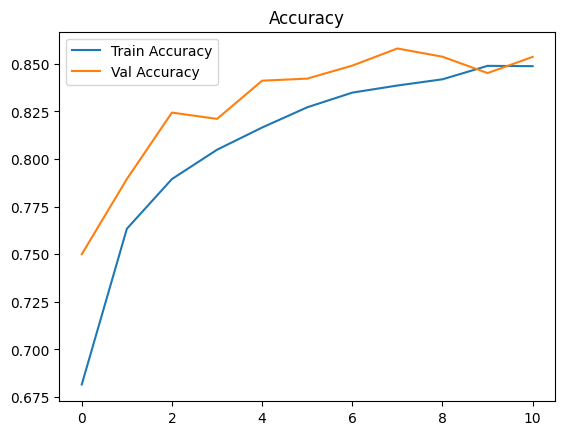

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


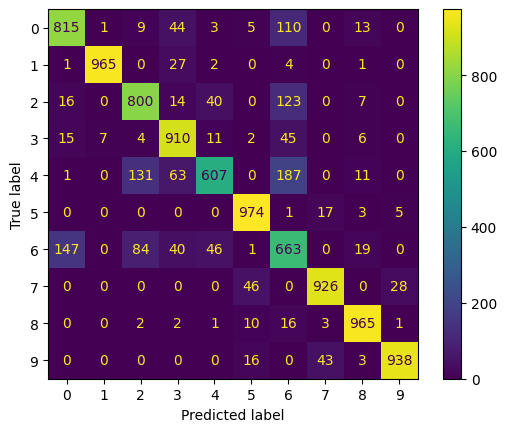

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [17]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [21]:
print(class_names[y_pred_classes[5999]])
print(y_test[5999])

T-shirt/top
0


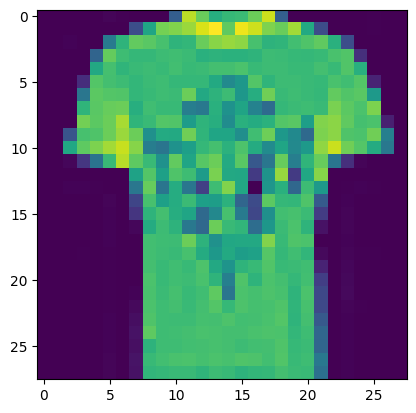

In [22]:
plt.imshow(x_test[5999])